# 🚗 Đếm Phương Tiện — LocateAnything-3B + Supervision

**Bật GPU T4 + Internet → Run All**

## Ghi chu sua loi (Claude da sua)

**Loi goc:** `TypeError: LocateAnythingPreTrainedModel._check_and_adjust_attn_implementation() got an unexpected keyword argument 'allow_all_kernels'`

**Nguyen nhan:** Cell cai dat thu vien dung `"transformers>=4.46.0"` (khong gioi han tran), nen pip tu lay ban **moi nhat** hien co la `5.14.1`. Code tuy chinh (`trust_remote_code=True`) cua `nvidia/LocateAnything-3B` duoc viet khop voi API cua **transformers 4.x** va chua biet ve tham so `allow_all_kernels` ma ham noi bo `_check_and_adjust_attn_implementation()` cua **transformers 5.x** them vao => mismatch chu ky ham => loi TypeError khi khoi tao model.

**Cach sua:**
1. Ghim dung phien ban `transformers==4.57.1` (ban chinh thuc NVIDIA da cong bo va test trong README cua model tren Hugging Face) thay vi de pip tu chon ban moi nhat.
2. Dong bo them cac goi ma NVIDIA da test cung: `opencv-python-headless==4.11.0.86`, `Pillow==11.1.0`, `decord==0.6.0`, `lmdb==1.7.5`, them `peft` (rieng `numpy` van giu `<2.0.0` vi ban `1.25.0` NVIDIA de nghi khong co wheel cho Python 3.12 cua Kaggle — ban `1.26.x` da duoc kiem chung la chay on).
3. Them `attn_implementation="sdpa"` khi load model — vi GPU **T4 (kien truc Turing)** khong nam trong danh sach GPU NVIDIA chinh thuc test (ho chi test Ampere/Hopper/Lovelace/Blackwell tro len), nen ep dung SDPA (co san trong PyTorch, khong can cai them flash-attn) de tranh viec model tu dong chon backend attention khong tuong thich voi T4.

**Sau khi sua:** Chon **Run All** tu dau. O Cell 1, kernel se tu khoi dong lai (do `os._exit(0)`) sau khi cai xong thu vien — day la hanh vi binh thuong, cu de Kaggle tiep tuc chay cac cell con lai. Kiem tra output cua Cell 2 phai in ra `transformers: 4.57.1` (khong con la `5.14.1`) truoc khi chay tiep cac cell sau.


---

## Cap nhat sua loi lan 2

**Loi moi:** `AttributeError: 'numpy.ndarray' object has no attribute 'is_floating_point'` trong `detect_pil()`.

**Nguyen nhan:** Processor tuy chinh (`trust_remote_code`) cua `nvidia/LocateAnything-3B` **khong luon tra ve `torch.Tensor` cho moi truong**, du da truyen `return_tensors="pt"` — vi du truong `image_grid_hws` van la `numpy.ndarray` (mot vi du chinh thuc khac tu cong dong phai tu wrap `torch.tensor(inputs["image_grid_hws"])` de xu ly dieu nay). Vi `numpy.ndarray` cung co thuoc tinh `.dtype` nen dieu kien `hasattr(v,"dtype")` van dung, nhung no khong co method `.is_floating_point()` (chi ton tai o `torch.Tensor`) => AttributeError.

**Cach sua:** them method `_prep_input()` trong class `LocateAnythingDetector` — chuyen `numpy.ndarray` thanh `torch.Tensor` truoc (`torch.from_numpy`), sau do moi kiem tra kieu du lieu (so thuc -> `.to(device, dtype=torch.float16)`, so nguyen -> `.to(device)`), cac gia tri khac (list, str, None...) giu nguyen. Da thay doan dict-comprehension cu bang `inputs = {k: self._prep_input(v) for k, v in inputs.items()}`.


In [ ]:
# Cell 1: Cai dat thu vien (transformers duoc GHIM CHINH XAC ban 4.57.1)
# NGUYEN NHAN LOI GOC: cau lenh cu dung "transformers>=4.46.0" (khong gioi han tran)
# => pip tu dong lay ban MOI NHAT hien co (5.14.1), nhung code tuy chinh (trust_remote_code)
# cua nvidia/LocateAnything-3B duoc viet cho API cua transformers 4.x, chua ho tro tham so
# moi "allow_all_kernels" ma transformers 5.x dua vao ham _check_and_adjust_attn_implementation().
# => Ghim dung ban 4.57.1 (ban NVIDIA da test chinh thuc trong README cua model) la du de het loi.
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless
!pip install -q -U "numpy<2.0.0" "transformers==4.57.1" "opencv-python-headless==4.11.0.86" "Pillow==11.1.0" "decord==0.6.0" "lmdb==1.7.5" accelerate peft "supervision>=0.21" matplotlib

print("Da cai xong toan bo (transformers ghim dung ban 4.57.1 theo khuyen nghi cua NVIDIA)!")
print("Dang tu dong khoi dong lai Kernel ngam...")
import os
# os._exit(00)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 65.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 29.6 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 76.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 64.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 81.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 21.5 MB/s eta 0:

In [2]:
# Cell 2: Imports
import os, re, sys, time, types, glob, shutil
import torch, cv2
import numpy as np
import supervision as sv
import transformers
from PIL import Image
from dataclasses import dataclass
from typing import List, Tuple
import matplotlib.pyplot as plt
from IPython.display import Video, display

print(f"transformers: {transformers.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} | {p.total_memory/1024**3:.1f}GB | sm_{p.major}{p.minor}")


transformers: 4.57.1
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4 | 14.6GB | sm_75


✅ Đã tìm thấy video: /kaggle/input/datasets/huyhung2004/couting/istockphoto-2179809582-640_adpp_is.mp4


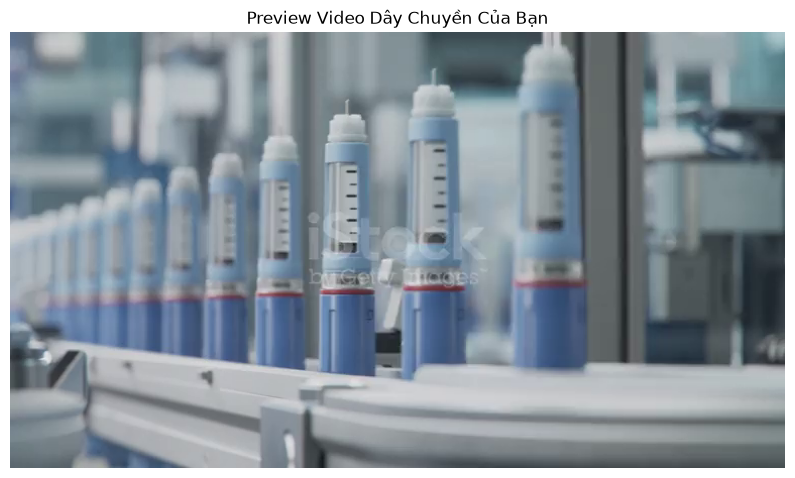

In [1]:
# Cell 3: Đọc video dây chuyền sản xuất mà bạn đã Upload
import os
import cv2
import matplotlib.pyplot as plt

# Đường dẫn ĐÚNG tới file video bạn vừa upload trong mục Input
VIDEO_PATH = "/kaggle/input/datasets/huyhung2004/couting/istockphoto-2179809582-640_adpp_is.mp4"

if not os.path.exists(VIDEO_PATH):
    print(f"❌ Không tìm thấy file tại {VIDEO_PATH}. Hãy kiểm tra lại tên thư mục Dataset!")
else:
    print(f"✅ Đã tìm thấy video: {VIDEO_PATH}")
    cap = cv2.VideoCapture(VIDEO_PATH)
    ret, preview = cap.read(); cap.release()
    
    if ret:
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
        plt.title("Preview Video Dây Chuyền Của Bạn")
        plt.axis("off"); plt.show()
    else:
        print("❌ Lỗi không đọc được khung hình từ video.")

In [4]:
# Cell 4: Download model + patch bfloat16 cho T4
from huggingface_hub import snapshot_download

MODEL_ID = "nvidia/LocateAnything-3B"
print("📥 Downloading model... (lần đầu ~6GB)")
model_dir = snapshot_download(MODEL_ID)
print(f"📁 {model_dir}")

# Xóa module cache cũ
mc = os.path.expanduser("~/.cache/huggingface/modules/transformers_modules")
if os.path.exists(mc):
    shutil.rmtree(mc)
    print("🗑️ Cleared modules cache")

# CHỈ 1 PATCH DUY NHẤT: T4 không hỗ trợ bfloat16 CUDA kernel
f = os.path.join(model_dir, "modeling_locateanything.py")
if os.path.exists(f):
    real_f = os.path.realpath(f)
    code = open(real_f).read()
    old = "pixel_values = pixel_values.to(self.language_model.dtype)"
    if old in code:
        code = code.replace(old, "pixel_values = pixel_values.to(torch.float16)  # T4 fix")
        open(real_f, "w").write(code)
        print("✅ Patched: bfloat16 → float16")
    else:
        print("ℹ️ Already patched")

print("✅ Ready!")


📥 Downloading model... (lần đầu ~6GB)


Fetching 47 files:   0%|          | 0/47 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

LICENSE: 0.00B [00:00, ?B/s]

...

training_args.bin:   0%|          | 0.00/7.29k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

trainer_state.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

📁 /root/.cache/huggingface/hub/models--nvidia--LocateAnything-3B/snapshots/c32291ca5e996f5a7a485845b4f57a233936bba0
✅ Patched: bfloat16 → float16
✅ Ready!


In [5]:
# Cell 5: Define Detector Class
from transformers import AutoTokenizer, AutoProcessor, AutoConfig, AutoModel
import torch
import time
import re
import numpy as np
from PIL import Image
import cv2
from dataclasses import dataclass
from typing import Tuple

@dataclass
class Detection:
    bbox: Tuple[int, int, int, int]
    class_name: str
    confidence: float

class LocateAnythingDetector:
    def __init__(self, model_dir, max_new_tokens=1024):
        self.model_dir = model_dir
        self.max_new_tokens = max_new_tokens
        self._loaded = False
        self.dtype = torch.float16 # T4 uses float16
        
    def load(self):
        t0 = time.time()
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_dir, trust_remote_code=True)
        self.processor = AutoProcessor.from_pretrained(self.model_dir, trust_remote_code=True)
        config = AutoConfig.from_pretrained(self.model_dir, trust_remote_code=True)
        self.model = AutoModel.from_pretrained(
            self.model_dir, config=config, 
            trust_remote_code=True, torch_dtype=self.dtype, 
            device_map="auto", attn_implementation="sdpa"
        )
        self.model.eval()
        self._loaded = True
        print(f"✅ Loaded in {time.time()-t0:.1f}s")
        if torch.cuda.is_available():
            print(f"   GPU Mem: {torch.cuda.memory_allocated()/1024**3:.1f} GB")

    def _prep_input(self, v):
        if isinstance(v, np.ndarray):
            v = torch.from_numpy(v)
        if torch.is_tensor(v):
            if v.is_floating_point():
                return v.to(device=self.model.device, dtype=torch.float16)
            return v.to(self.model.device)
        return v

    def detect_pil(self, pil_image, prompt, max_new_tokens=None):
        if not self._loaded: self.load()
        w, h = pil_image.size
        max_tok = max_new_tokens or self.max_new_tokens
        
        messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": f"Locate all instances of: {prompt}"}]}]
        text_prompt = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        
        inputs = self.processor(text=text_prompt, images=[pil_image], return_tensors="pt")
        inputs = {k: self._prep_input(v) for k, v in inputs.items()}
        
        with torch.no_grad():
            output = self.model.generate(**inputs, max_new_tokens=max_tok, do_sample=False, use_cache=True, tokenizer=self.tokenizer)
            
        if isinstance(output, (list, tuple)) and hasattr(output[0], "shape"):
            raw = self.tokenizer.decode(output[0], skip_special_tokens=True)
        elif hasattr(output, "shape"):
            raw = self.tokenizer.decode(output, skip_special_tokens=True)
        else:
            raw = str(output)
            
        return self._parse(raw, prompt, w, h), raw

    def detect_frame(self, bgr_frame, prompt, max_new_tokens=None):
        pil = Image.fromarray(cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB))
        return self.detect_pil(pil, prompt, max_new_tokens)

    def _parse(self, text, cls, w, h):
        dets = []
        # Pattern 1: <box><123><456><789><012></box>
        for m in re.findall(r'<box><(\d+)><(\d+)><(\d+)><(\d+)></box>', text):
            x1, y1, x2, y2 = [int(v) for v in m]
            x1, x2 = int(x1/1000*w), int(x2/1000*w)
            y1, y2 = int(y1/1000*h), int(y2/1000*h)
            if x2 > x1 and y2 > y1:
                dets.append(Detection((x1, y1, x2, y2), cls, 0.85))
        
        # Pattern 2: [x1, y1, x2, y2]
        if not dets:
            for m in re.findall(r'\[\s*([\d.]+)\s*,\s*([\d.]+)\s*,\s*([\d.]+)\s*,\s*([\d.]+)\s*\]', text):
                v = [float(x) for x in m]
                sc = 1000 if max(v) > 1.5 else 1
                x1, x2 = int(v[0]/sc*w), int(v[2]/sc*w)
                y1, y2 = int(v[1]/sc*h), int(v[3]/sc*h)
                if x2 > x1 and y2 > y1:
                    dets.append(Detection((x1, y1, x2, y2), cls, 0.85))
                    
        # Pattern 3: <loc_123> 
        if not dets:
            locs = re.findall(r'<loc_(\d+)>', text)
            for i in range(0, len(locs)-3, 4):
                x1, y1, x2, y2 = [int(v) for v in locs[i:i+4]]
                x1, x2 = int(x1/1000*w), int(x2/1000*w)
                y1, y2 = int(y1/1000*h), int(y2/1000*h)
                if x2 > x1 and y2 > y1:
                    dets.append(Detection((x1, y1, x2, y2), cls, 0.85))
                    
        return dets

In [6]:
# Cell 6: Load model
detector = LocateAnythingDetector(model_dir=model_dir, max_new_tokens=1024)
detector.load()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!
Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Loaded in 11.5s
   GPU Mem: 3.6 GB


In [ ]:
# Cell 7: Test 1 frame
cap = cv2.VideoCapture(VIDEO_PATH)
ret, test_frame = cap.read(); cap.release()

# 🛠️ VÁ LỖI TRÀN RAM: Thu nhỏ ảnh xuống 720p trước khi nhận diện
test_frame = cv2.resize(test_frame, (1280, 720))

PROMPT = "object"
print(f"🔍 Detecting: {PROMPT}")
t0 = time.time()
test_dets, raw_out = detector.detect_frame(test_frame, PROMPT)
elapsed = time.time() - t0
print(f"⏱️ {elapsed:.2f}s — {len(test_dets)} objects")
print(f"Raw: {raw_out[:500]}")

if test_dets:
    bboxes = np.array([d.bbox for d in test_dets], dtype=np.float32)
    sv_d = sv.Detections(
        xyxy=bboxes, 
        confidence=np.array([d.confidence for d in test_dets]),
        class_id=np.zeros(len(test_dets), dtype=int)
    )
    
    ann = sv.BoxAnnotator(thickness=2).annotate(test_frame.copy(), sv_d)
    ann = sv.LabelAnnotator(text_scale=0.5).annotate(ann, sv_d, labels=[f"{d.class_name} {d.confidence:.0%}" for d in test_dets])
    
    plt.figure(figsize=(14, 9))
    plt.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
    plt.title(f"{len(test_dets)} detected ({elapsed:.2f}s)")
    plt.axis("off")
    plt.show()
else:
    print("⚠️ No detections")

In [ ]:
# Cell 8: MÔ-ĐUN ĐẾM ĐA NĂNG (Traffic & Conveyor)
import time, cv2, numpy as np, supervision as sv
import os, urllib.request

# =====================================================================
# 🎛️ BẢNG ĐIỀU KHIỂN: CHỌN CHẾ ĐỘ TEST BẠN MUỐN CHẠY
# Đổi giá trị chữ bên dưới thành "traffic" hoặc "conveyor"
# =====================================================================
CHOOSE_VIDEO = "traffic"  # <--- HÃY SỬA Ở ĐÂY

if CHOOSE_VIDEO == "traffic":
    print("🚗 CHẾ ĐỘ: ĐẾM XE GIAO THÔNG")
    PROMPT = "car"
    VIDEO_PATH = "/kaggle/working/vehicles.mp4"
    OUTPUT_PATH = "/kaggle/working/traffic_counting.mp4"
    # Tự động tải video giao thông nếu chưa có trong máy ảo
    if not os.path.exists(VIDEO_PATH):
        print("📥 Đang tải video giao thông...")
        urllib.request.urlretrieve("https://media.roboflow.com/supervision/video-examples/vehicles.mp4", VIDEO_PATH)

elif CHOOSE_VIDEO == "conveyor":
    print("🏭 CHẾ ĐỘ: ĐẾM SẢN PHẨM BĂNG CHUYỀN")
    PROMPT = "object"
    # Đường dẫn chuẩn tới video bạn đã Upload:
    VIDEO_PATH = "/kaggle/input/datasets/huyhung2004/couting/istockphoto-2179809582-640_adpp_is.mp4"
    OUTPUT_PATH = "/kaggle/working/conveyor_counting.mp4"

# =====================================================================

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    print(f"❌ LỖI: Không tìm thấy video tại {VIDEO_PATH}")
else:
    w, h = 1280, 720
    fps = cap.get(cv2.CAP_PROP_FPS) or 30

    # 📐 TỰ ĐỘNG CHỈNH VẠCH ĐẾM THEO CHẾ ĐỘ
    if CHOOSE_VIDEO == "traffic":
        # Giao thông: Vạch ngang ở nửa dưới màn hình
        line_y = int(h * 0.55)
        line_zone = sv.LineZone(start=sv.Point(0, line_y), end=sv.Point(w, line_y), triggering_anchors=(sv.Position.BOTTOM_CENTER,))
    else:
        # Băng chuyền: Vạch dọc chia đôi màn hình
        line_zone = sv.LineZone(start=sv.Point(w // 2, 0), end=sv.Point(w // 2, h), triggering_anchors=(sv.Position.CENTER,))

    tracker = sv.ByteTrack(frame_rate=int(fps))
    box_ann = sv.BoxAnnotator(thickness=2)
    label_ann = sv.LabelAnnotator(text_scale=0.5)
    trace_ann = sv.TraceAnnotator(thickness=2, trace_length=20)
    line_ann = sv.LineZoneAnnotator(thickness=3, text_scale=1.0)

    writer = cv2.VideoWriter(OUTPUT_PATH, cv2.VideoWriter_fourcc(*"mp4v"), int(fps), (w, h))
    processed, total_t = 0, 0
    MAX_FRAMES = 150 # Bạn có thể tăng số này lên nếu muốn video dài hơn

    while processed < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret: break
        
        frame = cv2.resize(frame, (w, h))
        processed += 1
        t0 = time.time()
        dets, _ = detector.detect_frame(frame, PROMPT)
        total_t += (time.time() - t0)

        if dets:
            sv_d = sv.Detections(
                xyxy=np.array([d.bbox for d in dets], dtype=np.float32), 
                confidence=np.array([d.confidence for d in dets], dtype=np.float32), 
                class_id=np.zeros(len(dets), dtype=int)
            )
        else:
            sv_d = sv.Detections.empty()
            
        sv_d = tracker.update_with_detections(sv_d)
        line_zone.trigger(sv_d)
        
        a = frame.copy()
        a = trace_ann.annotate(a, sv_d)
        a = box_ann.annotate(a, sv_d)
        
        if len(sv_d) > 0 and sv_d.tracker_id is not None:
            labels = [f"#{t}" for t in sv_d.tracker_id]
            a = label_ann.annotate(a, sv_d, labels)
            
        a = line_ann.annotate(a, line_zone)
        
        cv2.putText(a, f"COUNTED: {line_zone.in_count + line_zone.out_count}", (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
        writer.write(a)

    writer.release()
    cap.release()
    print(f"✅ Hoàn thành! Video lưu tại: {OUTPUT_PATH}")

In [ ]:
# Cell 9: Xem kết quả thông minh
import os
from IPython.display import Video, display

# Tự động lấy đường dẫn đầu ra từ Cell 8
H264 = OUTPUT_PATH.replace(".mp4", "_h264.mp4")

print(f"⏳ Đang xử lý định dạng video cho: {OUTPUT_PATH}...")
os.system(f"ffmpeg -y -i {OUTPUT_PATH} -vcodec libx264 {H264} 2>/dev/null")

if os.path.exists(H264):
    display(Video(H264, embed=True, width=900))
else:
    print("⚠️ Lỗi hiển thị video")

In [ ]:
# Cell 10: Test mô hình trên Dataset ảnh từ Roboflow
import glob
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv

# 🛑 TỰ ĐỘNG TÌM FILE ẢNH TRONG THƯ MỤC TEST
base_path = "/kaggle/input/datasets/huyhung2004/package/test"
image_files = glob.glob(f"{base_path}/images/*.jpg")

# Nếu không tìm thấy trong thư mục con 'images', thử tìm trực tiếp ở ngoài
if not image_files:
    image_files = glob.glob(f"{base_path}/*.jpg")

if not image_files:
    print(f"❌ Vẫn không tìm thấy ảnh! Bạn thử mở cột Input bên phải để check lại đường dẫn xem ảnh có bị sai định dạng đuôi không nhé.")
else:
    print(f"✅ Đã tìm thấy {len(image_files)} ảnh để test!")
    
    # Lấy ngẫu nhiên 3 bức ảnh để AI test thử
    sample_images = random.sample(image_files, min(3, len(image_files)))
    
    # Dùng prompt là "box" (hộp hàng)
    PROMPT = "box" 

    plt.figure(figsize=(18, 6))
    
    for i, img_path in enumerate(sample_images):
        frame = cv2.imread(img_path)
        frame = cv2.resize(frame, (1280, 720))
        
        # Gọi AI nhận diện
        dets, _ = detector.detect_frame(frame, PROMPT)
        
        # Xử lý vẽ khung (Bounding Box) nếu AI tìm thấy đồ vật
        if dets:
            bboxes = np.array([d.bbox for d in dets], dtype=np.float32)
            confidences = np.array([d.confidence for d in dets], dtype=np.float32)
            class_ids = np.zeros(len(dets), dtype=int)
            
            sv_d = sv.Detections(
                xyxy=bboxes, 
                confidence=confidences,
                class_id=class_ids
            )
            
            # Cài đặt nét vẽ và chữ
            box_ann = sv.BoxAnnotator(thickness=3)
            label_ann = sv.LabelAnnotator(text_scale=0.7)
            
            # Vẽ lên ảnh
            annotated_frame = box_ann.annotate(scene=frame.copy(), detections=sv_d)
            labels = [f"{PROMPT} {c:.2f}" for c in confidences]
            annotated_frame = label_ann.annotate(scene=annotated_frame, detections=sv_d, labels=labels)
        else:
            annotated_frame = frame.copy()
            
        # Hiển thị kết quả ra màn hình
        plt.subplot(1, 3, i+1)
        plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
        plt.title(f"Ảnh {i+1} | Phát hiện: {len(dets)} vật")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

⏳ Bắt đầu tính toán trên 153 bức ảnh (Vui lòng đợi)...


100%|██████████| 153/153 [44:36<00:00, 17.49s/it]



✅ Quá trình quét hoàn tất! Đang vẽ biểu đồ...


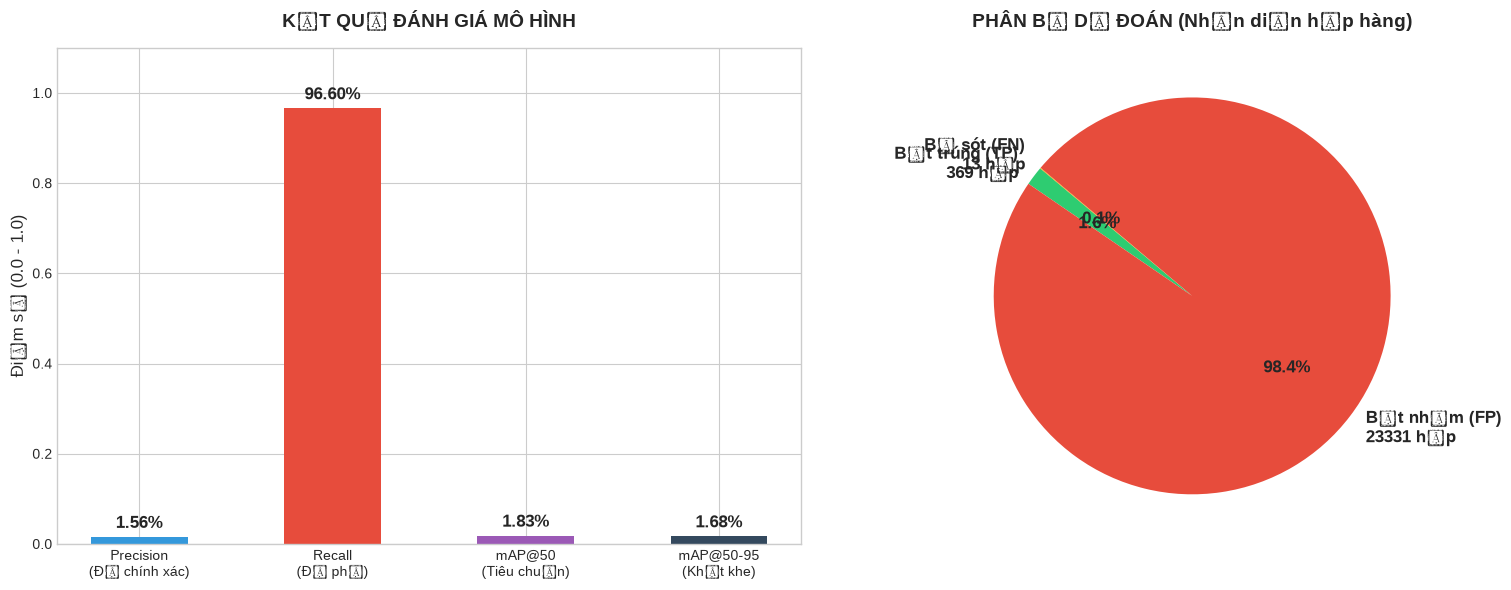

In [8]:
# Cell 11: Đánh giá mAP, Precision, Recall và Vẽ biểu đồ
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
from tqdm import tqdm

PROMPT = "cardboard box"

# 1. QUÉT ĐƯỜNG DẪN ẢNH VÀ NHÃN (GROUND TRUTH)
base_path = "/kaggle/input/datasets/huyhung2004/package/test"
image_paths = sorted(glob.glob(f"{base_path}/images/*.jpg"))
if not image_paths:
    image_paths = sorted(glob.glob(f"{base_path}/*.jpg"))

label_paths = [p.replace("/images/", "/labels/").replace(".jpg", ".txt") for p in image_paths]

targets = []
predictions = []

# 🛑 MẸO NHỎ: Nếu bạn muốn chạy NHANH 10 ảnh để xem biểu đồ hiển thị ra sao trước, 
# hãy sửa dòng dưới thành MAX_TEST = 10. Còn để nguyên thì nó sẽ quét full 153 ảnh.
MAX_TEST = len(image_paths) 
test_imgs = image_paths[:MAX_TEST]
test_lbls = label_paths[:MAX_TEST]

print(f"⏳ Bắt đầu tính toán trên {MAX_TEST} bức ảnh (Vui lòng đợi)...")

for img_p, lbl_p in tqdm(zip(test_imgs, test_lbls), total=MAX_TEST):
    frame = cv2.imread(img_p)
    if frame is None: continue
    h, w = frame.shape[:2]

    # --- ĐỌC NHÃN CHUẨN TỪ DATASET (GROUND TRUTH) ---
    gt_bboxes = []
    if os.path.exists(lbl_p):
        with open(lbl_p, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    xc, yc, bw, bh = map(float, parts[1:5])
                    x1 = (xc - bw/2) * w
                    y1 = (yc - bh/2) * h
                    x2 = (xc + bw/2) * w
                    y2 = (yc + bh/2) * h
                    gt_bboxes.append([x1, y1, x2, y2])

    if gt_bboxes:
        targets.append(sv.Detections(
            xyxy=np.array(gt_bboxes, dtype=np.float32),
            class_id=np.zeros(len(gt_bboxes), dtype=int)
        ))
    else:
        targets.append(sv.Detections.empty())

    # --- CHO AI DỰ ĐOÁN (PREDICTIONS) ---
    frame_resized = cv2.resize(frame, (1280, 720))
    dets, _ = detector.detect_frame(frame_resized, PROMPT)

    if dets:
        pred_bboxes = []
        pred_confs = []
        for d in dets:
            rx1 = d.bbox[0] * w / 1280
            ry1 = d.bbox[1] * h / 720
            rx2 = d.bbox[2] * w / 1280
            ry2 = d.bbox[3] * h / 720
            pred_bboxes.append([rx1, ry1, rx2, ry2])
            pred_confs.append(d.confidence)

        predictions.append(sv.Detections(
            xyxy=np.array(pred_bboxes, dtype=np.float32),
            confidence=np.array(pred_confs, dtype=np.float32),
            class_id=np.zeros(len(dets), dtype=int)
        ))
    else:
        predictions.append(sv.Detections.empty())

print("\n✅ Quá trình quét hoàn tất! Đang vẽ biểu đồ...")

# =====================================================================
# 2. TÍNH TOÁN CÁC CHỈ SỐ
# =====================================================================
conf_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions, targets=targets, classes=[PROMPT], conf_threshold=0.5, iou_threshold=0.5
)

cm = conf_matrix.matrix
TP = cm[0, 0] # True Positive (Trúng)
FN = cm[0, 1] # False Negative (Sót)
FP = cm[1, 0] # False Positive (Nhầm)

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

map_metric = sv.MeanAveragePrecision.from_detections(predictions=predictions, targets=targets)
map50 = map_metric.map50
map50_95 = map_metric.map50_95

# =====================================================================
# 3. VẼ BIỂU ĐỒ (VISUALIZATION)
# =====================================================================
# Cài đặt phông nền trắng cho biểu đồ đẹp hơn
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---- BIỂU ĐỒ CỘT: Các chỉ số mAP, Precision, Recall ----
metrics = ['Precision\n(Độ chính xác)', 'Recall\n(Độ phủ)', 'mAP@50\n(Tiêu chuẩn)', 'mAP@50-95\n(Khắt khe)']
scores = [precision, recall, map50, map50_95]
colors = ['#3498db', '#e74c3c', '#9b59b6', '#34495e']

bars = ax1.bar(metrics, scores, color=colors, width=0.5)
ax1.set_ylim(0, 1.1)
ax1.set_title('KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Điểm số (0.0 - 1.0)', fontsize=12)

# Ghi số % lên đỉnh các cột
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2%}", ha='center', fontsize=12, fontweight='bold')

# ---- BIỂU ĐỒ TRÒN: Tỷ lệ Bắt Trúng / Bắt Sót / Bắt Nhầm ----
labels = [f'Bắt trúng (TP)\n{int(TP)} hộp', f'Bắt nhầm (FP)\n{int(FP)} hộp', f'Bỏ sót (FN)\n{int(FN)} hộp']
sizes = [TP, FP, FN]
pie_colors = ['#2ecc71', '#e74c3c', '#f39c12']

# Lọc các giá trị > 0 để biểu đồ không bị lỗi nếu có chỉ số bằng 0
fl_labels = [l for l, s in zip(labels, sizes) if s > 0]
fl_sizes = [s for s in sizes if s > 0]
fl_colors = [c for c, s in zip(pie_colors, sizes) if s > 0]

if fl_sizes:
    ax2.pie(fl_sizes, labels=fl_labels, colors=fl_colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12, 'fontweight':'bold'})
    ax2.set_title('PHÂN BỔ DỰ ĐOÁN (Nhận diện hộp hàng)', fontsize=14, fontweight='bold', pad=15)
else:
    ax2.text(0.5, 0.5, "Không có dữ liệu dự đoán", ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

In [9]:
# Cell 13: Xuất toàn bộ 153 ảnh so sánh (Nhãn gốc vs AI) ra thư mục để kiểm tra
import os
import glob
import cv2
import numpy as np
import supervision as sv
from tqdm import tqdm

PROMPT = "box"
CONF_THRESH = 0.5  # Lọc bớt rác dưới 50%
OUT_DIR = "/kaggle/working/test_results"

# Tạo thư mục chứa kết quả
os.makedirs(OUT_DIR, exist_ok=True)

# Lấy toàn bộ ảnh test
base_path = "/kaggle/input/datasets/huyhung2004/package/test"
image_files = sorted(glob.glob(f"{base_path}/images/*.jpg"))
if not image_files:
    image_files = sorted(glob.glob(f"{base_path}/*.jpg"))

print(f"⏳ Đang ghép và lưu {len(image_files)} ảnh so sánh (Quá trình này tốn khoảng 5-10 phút)...")

for img_p in tqdm(image_files):
    img_name = os.path.basename(img_p)
    frame = cv2.imread(img_p)
    if frame is None: continue
    h, w = frame.shape[:2]

    lbl_p = img_p.replace("/images/", "/labels/").replace(".jpg", ".txt")

    # ==========================================
    # 1. NHÃN GỐC (BÊN TRÁI)
    # ==========================================
    gt_bboxes = []
    if os.path.exists(lbl_p):
        with open(lbl_p, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    xc, yc, bw, bh = map(float, parts[1:5])
                    x1, y1 = (xc - bw/2) * w, (yc - bh/2) * h
                    x2, y2 = (xc + bw/2) * w, (yc + bh/2) * h
                    gt_bboxes.append([x1, y1, x2, y2])
    
    gt_frame = frame.copy()
    if gt_bboxes:
        gt_sv = sv.Detections(xyxy=np.array(gt_bboxes, dtype=np.float32), class_id=np.zeros(len(gt_bboxes), int))
        gt_frame = sv.BoxAnnotator(thickness=4).annotate(gt_frame, gt_sv)
        
    # Ghi chú lên góc ảnh trái
    cv2.putText(gt_frame, "NHAN GOC (Ground Truth)", (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 4)

    # ==========================================
    # 2. AI DỰ ĐOÁN (BÊN PHẢI)
    # ==========================================
    frame_resized = cv2.resize(frame, (1280, 720))
    dets, _ = detector.detect_frame(frame_resized, PROMPT)
    
    pred_frame = frame.copy()
    if dets:
        pred_bboxes, pred_confs = [], []
        for d in dets:
            if d.confidence >= CONF_THRESH:
                rx1, ry1 = d.bbox[0] * w / 1280, d.bbox[1] * h / 720
                rx2, ry2 = d.bbox[2] * w / 1280, d.bbox[3] * h / 720
                pred_bboxes.append([rx1, ry1, rx2, ry2])
                pred_confs.append(d.confidence)
                
        if pred_bboxes:
            pred_sv = sv.Detections(
                xyxy=np.array(pred_bboxes, dtype=np.float32), 
                class_id=np.ones(len(pred_bboxes), int), 
                confidence=np.array(pred_confs, dtype=np.float32)
            )
            pred_frame = sv.BoxAnnotator(thickness=4).annotate(pred_frame, pred_sv)
            labels = [f"AI {c:.2f}" for c in pred_confs]
            pred_frame = sv.LabelAnnotator(text_scale=1.0).annotate(pred_frame, pred_sv, labels=labels)

    # Ghi chú lên góc ảnh phải
    cv2.putText(pred_frame, f"AI PREDICT (Conf > {CONF_THRESH})", (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 4)

    # ==========================================
    # 3. GHÉP 2 ẢNH VÀ LƯU RA FILE
    # ==========================================
    # Ghép 2 ảnh cạnh nhau theo chiều ngang (Horizontal)
    combined_img = cv2.hconcat([gt_frame, pred_frame])
    
    # Lưu ra file trong thư mục test_results
    out_path = os.path.join(OUT_DIR, img_name)
    cv2.imwrite(out_path, combined_img)

print(f"\n✅ Hoàn thành! 153 bức ảnh đã được lưu tại thư mục: {OUT_DIR}")

⏳ Đang ghép và lưu 153 ảnh so sánh (Quá trình này tốn khoảng 5-10 phút)...


100%|██████████| 153/153 [43:23<00:00, 17.02s/it]


✅ Hoàn thành! 153 bức ảnh đã được lưu tại thư mục: /kaggle/working/test_results
